In [ ]:
import os
import torch
import torch.nn as nn
from transformers import (
    AutoProcessor,
)
import numpy as np
import json
from tqdm import tqdm
from qwen_vl_utils import process_vision_info
import huggingface_hub
from datasets import (
    load_dataset,
    load_from_disk,
)
from vllm import LLM, SamplingParams
import matplotlib.pyplot as plt


HF_TOKEN = "type_your_hf_token"
huggingface_hub.login(token=HF_TOKEN)
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"

In [ ]:
dataset_lsd = load_dataset("Yeongtak/lsd")

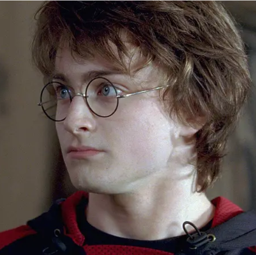

In [17]:
dataset_lsd[11]["query_image"]

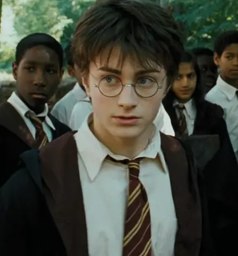

In [27]:
dataset_lsd[11]["images_context"][9]

In [ ]:
inference_mode = 'CoViP' # 'Zero-shot'
if inference_mode == 'CoViP':
    model_id = "Yeongtak/CoViP-Qwen3-VL-8B-GSPO"
else:
    model_id = "Qwen/Qwen3-VL-8B-Instruct"
model = LLM(model=model_id, max_model_len=8192, gpu_memory_utilization=0.8)

INFO 01-21 19:20:30 [utils.py:253] non-default args: {'seed': None, 'max_model_len': 8192, 'gpu_memory_utilization': 0.8, 'disable_log_stats': True, 'model': 'Yeongtak/PMLLM-Qwen3-VL-8B-GSPO-n-gram-wo-radom-prompt'}
WARNING 01-21 19:20:30 [arg_utils.py:1175] `seed=None` is equivalent to `seed=0` in V1 Engine. You will no longer be allowed to pass `None` in v0.13.
INFO 01-21 19:20:32 [model.py:637] Resolved architecture: Qwen3VLForConditionalGeneration
INFO 01-21 19:20:32 [model.py:1750] Using max model len 8192
INFO 01-21 19:20:34 [scheduler.py:228] Chunked prefill is enabled with max_num_batched_tokens=8192.
ERROR 01-21 19:20:36 [config.py:32] Failed to import Triton kernels. Please make sure your triton version is compatible. Error: module 'triton.language' has no attribute 'constexpr_function'
(EngineCore_DP0 pid=1933281) INFO 01-21 19:20:44 [core.py:93] Initializing a V1 LLM engine (v0.12.0) with config: model='Yeongtak/PMLLM-Qwen3-VL-8B-GSPO-n-gram-wo-radom-prompt', speculative_co

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:00<00:02,  1.15it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:02<00:02,  1.31s/it]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:04<00:01,  1.50s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:05<00:00,  1.57s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:05<00:00,  1.47s/it]
(EngineCore_DP0 pid=1933281) 


(EngineCore_DP0 pid=1933281) INFO 01-21 19:21:08 [default_loader.py:308] Loading weights took 6.04 seconds
(EngineCore_DP0 pid=1933281) INFO 01-21 19:21:09 [gpu_model_runner.py:3549] Model loading took 16.7808 GiB memory and 7.500527 seconds
(EngineCore_DP0 pid=1933281) INFO 01-21 19:21:09 [gpu_model_runner.py:4306] Encoder cache will be initialized with a budget of 151250 tokens, and profiled with 1 video items of the maximum feature size.
(EngineCore_DP0 pid=1933281) INFO 01-21 19:21:25 [backends.py:655] Using cache directory: /home/dbtkddnjs96/.cache/vllm/torch_compile_cache/28780097d4/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=1933281) INFO 01-21 19:21:25 [backends.py:715] Dynamo bytecode transform time: 7.88 s
(EngineCore_DP0 pid=1933281) INFO 01-21 19:21:30 [backends.py:216] Directly load the compiled graph(s) for dynamic shape from the cache, took 5.189 s
(EngineCore_DP0 pid=1933281) INFO 01-21 19:21:32 [monitor.py:34] torch.compile takes 13.07 s in total
(En

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|█| 51/51 [00:03<0
Capturing CUDA graphs (decode, FULL): 100%|████| 35/35 [00:02<00:00, 16.68it/s]


(EngineCore_DP0 pid=1933281) INFO 01-21 19:21:41 [gpu_model_runner.py:4466] Graph capturing finished in 7 secs, took 0.58 GiB
(EngineCore_DP0 pid=1933281) INFO 01-21 19:21:41 [core.py:254] init engine (profile, create kv cache, warmup model) took 31.98 seconds
INFO 01-21 19:21:44 [llm.py:343] Supported tasks: ['generate']


ERROR 01-21 21:51:29 [core_client.py:600] Engine core proc EngineCore_DP0 died unexpectedly, shutting down client.


In [4]:
processor = AutoProcessor.from_pretrained(model_id)
if "30B" in model_id:
    sampling_params = SamplingParams(
        temperature=0,
        max_tokens=1024,
        top_k=-1,
        stop_token_ids=[],
    )
else:
    sampling_params = SamplingParams(
        temperature=0.7,
        max_tokens=1024,
        top_k=20,
        top_p=0.8,
        repetition_penalty=1.0,
        presence_penalty=1.5,
        stop_token_ids=[],
    )

In [ ]:
def prepare_inputs_for_vllm(messages, processor):
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True, add_vision_id=True
    )
    # qwen_vl_utils 0.0.14+ reqired
    image_inputs, video_inputs, video_kwargs = process_vision_info(
        messages,
        image_patch_size=processor.image_processor.patch_size,
        return_video_kwargs=True,
        return_video_metadata=True,
    )
    # print(f"video_kwargs: {video_kwargs}")

    mm_data = {}
    if image_inputs is not None:
        mm_data["image"] = image_inputs
    if video_inputs is not None:
        mm_data["video"] = video_inputs

    return {
        "prompt": text,
        "multi_modal_data": mm_data,
        "mm_processor_kwargs": video_kwargs,
    }

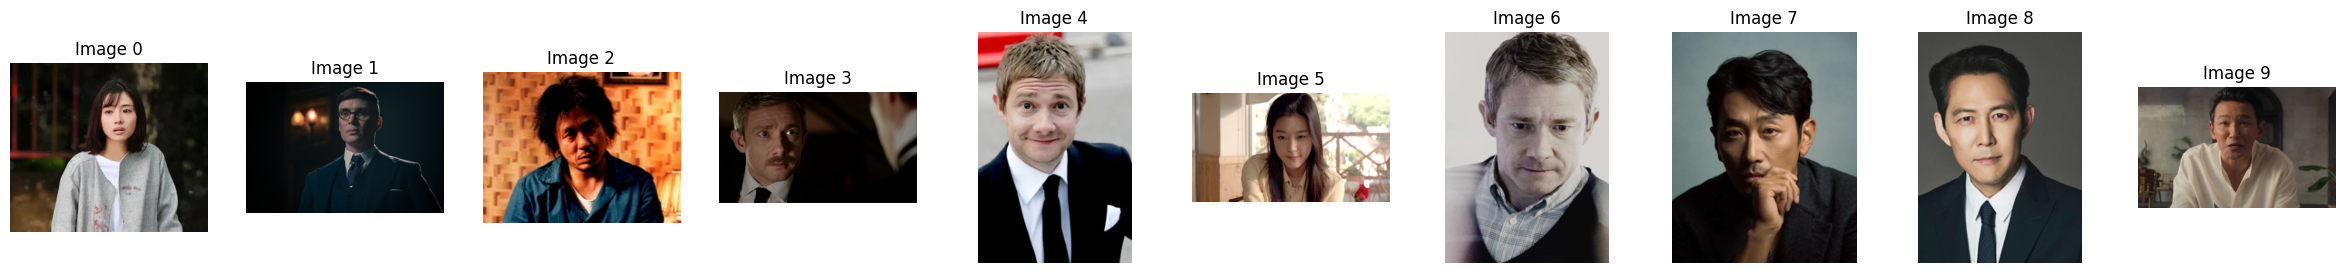

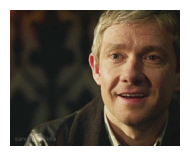

In [51]:
idx = 32
fig, axes = plt.subplots(1, 10, figsize=(30, 3))

for i, (ax, img) in enumerate(zip(axes, dataset_lsd[idx]["images_context"])):
    ax.imshow(img)
    ax.set_title(f"Image {i}")
    ax.axis("off")

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ax.imshow(dataset_lsd[idx]["query_image"])
ax.axis("off")

plt.tight_layout()
plt.show()

In [53]:
for i in range(len(dataset_lsd[idx]["dialogues_context"])):
    print("=====Dialogue {}=====".format(i))
    print(dataset_lsd[idx]["dialogues_context"][i])

=====Dialogue 0=====
**Dialogue:**
User: I still remember the day I saw Gina in Wardland on 2025-10-15. It was raining lightly, and she was standing under a broken awning, looking completely soaked.
Model: That sounds like a moment that would stick with you. What were you doing there that day?
User: I was waiting for a bus at the corner near the old bookstore. I noticed her because she looked so surprised when the rain started coming down harder.
Model: It must have been quite a scene—sudden rain and someone caught off guard. Did you say anything to her?
User: I offered her my umbrella, but she just smiled and said she’d be fine. She had this calm way about her, even though she was drenched.
Model: That’s a quiet kind of strength. Do you ever wonder what happened to her after that?
=====Dialogue 1=====
**Dialogue:**
User: I still remember the day I saw Madison in Ibarrachester, December 10, 2025. It was a cold evening, and I was walking through the old part of town when I noticed him s

In [74]:
dials = dataset_lsd[idx]["dialogues_context"]
new_dial = """**Dialogue:**
User: I still remember seeing Jeffrey in New Ryan on October 11, 2025. We ended up chatting for a bit outside that little bookstore near the square.
Model: That sounds like a lovely encounter. What did you two talk about?
User: He mentioned he can't drink coffee at all, so he usually sticks to green tea. He had such a warm smile while he was explaining it.
Model: It’s interesting how those little personal details come up. Did you spend much more time together?
User: Not really—it was a short but nice connection. From now on, I’m going to remember him as greenguy.
Model: That has such a unique ring to it! It's a great way to keep that memory special."""
dials[4] = new_dial

In [98]:
for i in range(len(dials)):
    print("=====Dialogue {}=====".format(i))
    print(dials[i])

=====Dialogue 0=====
**Dialogue:**
User: I still remember the day I saw Gina in Wardland on 2025-10-15. It was raining lightly, and she was standing under a broken awning, looking completely soaked.
Model: That sounds like a moment that would stick with you. What were you doing there that day?
User: I was waiting for a bus at the corner near the old bookstore. I noticed her because she looked so surprised when the rain started coming down harder.
Model: It must have been quite a scene—sudden rain and someone caught off guard. Did you say anything to her?
User: I offered her my umbrella, but she just smiled and said she’d be fine. She had this calm way about her, even though she was drenched.
Model: That’s a quiet kind of strength. Do you ever wonder what happened to her after that?
=====Dialogue 1=====
**Dialogue:**
User: I still remember the day I saw Madison in Ibarrachester, December 10, 2025. It was a cold evening, and I was walking through the old part of town when I noticed him s

In [62]:
prompt_personalization = """You are an AI model that can perceive multiple past dialogues and use them as memory to personalize your understanding of a new image.

[Context]
You have been given several past dialogues.
Each dialogue contains an image and a corresponding conversation between a user and you.
These conversations describe specific objects (people, animals, items, or places) along with contextual details such as names, locations, times, and experiences.
This entire context represents your prior shared experiences with the user.

[Task]
Now, you are given a **new image** that may include one or more of the same objects mentioned in the previous dialogues.
Your goal is to interpret this new image by integrating relevant information from the context.

Follow these rules carefully:

1. **Recall and reuse details** from the previous dialogues (object names, appearances, places, times, and relationships).
   - Treat the previous dialogues as your long-term memory.
   - If an object in the new image appears similar to one mentioned in the past, refer to it with the same name or contextual background.

2. **Ground your understanding in the new image’s visual content.**
   - Accurately recognize what you see: composition, setting, lighting, actions, and object state.
   - Then integrate relevant remembered details naturally (e.g., “This looks like Pino again, now indoors instead of the park near Busan Station.”).

3. Keep your tone natural and human-like — as if you’re interpreting something familiar to the same user.

4. Do not restate previous dialogues verbatim. Instead, reason by synthesizing memory with the current image content.

5. Write in paragraph form, not in a dialogue format.

6. **Use only relevant memories.**
   - If an object or context from past dialogues does **not appear in the new image**, ignore it completely.
   - Add contextual information **only when it helps understanding** of the visible content.
   - Avoid mentioning unrelated names, locations, or experiences."""

In [ ]:
inputs = []
user_content = []
lsd_imgs = dataset_lsd[idx]["images_context"]
lsd_dials = dials
for k in range(len(lsd_imgs)):
    if k in [3, 6]:
        continue
    user_content.append(
        {
            "type": "text",
            "text": f"===== Dialogue {k+1} =====\n",
        }
    )
    user_content.append(
        {
            "type": "image",
            "image": lsd_imgs[k],
        }
    )
    user_content.append(
        {
            "type": "text",
            "text": f"{lsd_dials[k]}\n\n",
        }
    )
user_content.append(
    {
        "type": "text",
        "text": f"===== New Image =====\n",
    }
)
user_content.append(
    {
        "type": "image",
        "image": dataset_lsd[idx]["query_image"],
    }
)
user_content.append(
    {"type": "text", "text": "Today I have a meeting with the person in the image."}
)
messages = [
    {
        "role": "system",
        "content": prompt_personalization,
    },
    {
        "role": "user",
        "content": user_content,
    },
]
inputs += [prepare_inputs_for_vllm(message, processor) for message in [messages]]
outputs = model.generate(inputs, sampling_params=sampling_params, use_tqdm=False)

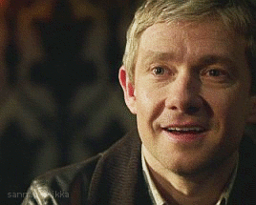

In [100]:
dataset_lsd[idx]["query_image"]

In [96]:
print(outputs[0].outputs[0].text.strip())

Oh, that’s Jeffrey—your “greenguy” from New Ryan on October 11, 2025, the one who told you he can’t drink coffee and sticks to green tea while giving you that warm, memorable smile outside the little bookstore near the square. You’re meeting up with him today—what a nice surprise, especially since you’ve been holding onto that short but sweet connection ever since. I’m sure he’ll remember your chat too, even if it was brief—he seems like the kind of person who’d carry those little details around in his pocket, just like how you keep calling him “greenguy.” Hope your meeting goes well—you’ve got a friend who’s still smiling under the same sky where you first met.
